In [2]:
import torch

In [3]:
import torch
import torch.nn as nn 
import torch.nn.functional as F


class SlotAttention(nn.Module):
    def __init__(self, num_slots, dim, iters=7, eps=1e-8):
        super().__init__()
        self.num_slots = num_slots
        self.iters = iters
        self.eps = eps 
        self.scale = dim ** -0.5 
        
        self.slots_mu = nn.Parameter(torch.randn(1, num_slots, dim))
        self.slots_sigma = nn.Parameter(torch.randn(1, num_slots, dim))

        self.to_q = nn.Linear(dim, dim)
        self.to_k = nn.Linear(dim, dim)
        self.to_v = nn.Linear(dim, dim)

        self.gru = nn.GRUCell(dim, dim)
        self.mlp = nn.Sequential(
                nn.Linear(dim, dim),
                nn.ReLU(),
                nn.Linear(dim ,dim)
                )

        self.norm_input = nn.LayerNorm(dim)
        self.norm_slots = nn.LayerNorm(dim)
        self.norm_pre_ff = nn.LayerNorm(dim)


    def forward(self, inputs):
        B, N, D = inputs.shape 

        inputs = self.norm_input(inputs)
        k = self.to_k(inputs)
        v = self.to_v(inputs)

        slots = self.slots_mu + F.softplus(self.slots_sigma) * torch.randn(B, self.num_slots, D, device=inputs.device)

        for _ in range(self.iters):
            slots_prev = slots 
            slots_norm = self.norm_slots(slots)
            q = self.to_q(slots_norm)

            attn_logits = torch.einsum('bid, bjd->bij', q, k) * self.scale 
            attn = F.softmax(attn_logits, dim=1) + self.eps 
            attn = attn/attn.sum(dim=-1, keepdim=True)

            updates = torch.einsum('bjd, bij->bid', v, attn)

            slots = self.gru(
                    updates.reshape(-1, D),
                    slots_prev.reshape(-1, D)
                    )

            slots = slots.reshape(B, -1, D)
            slots = slots + self.mlp(self.norm_pre_ff(slots))

        return slots 

In [4]:
import torch 
import torch.nn as nn 
import torch.nn.functional as F 

class Encoder(nn.Module):
    def __init__(self, in_channels=3, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
                nn.Conv2d(in_channels, hidden_dim, 5, padding=2),
                nn.ReLU(),
                nn.Conv2d(hidden_dim, hidden_dim, 5, padding=2),
                nn.ReLU(),
                nn.Conv2d(hidden_dim, hidden_dim, 5, padding=2),
                nn.ReLU()
        )
        self.pos_embd = nn.Parameter(torch.randn(1, hidden_dim, 64, 64)*0.02)
    
    def forward(self, x):
        B, C, H, W = x.shape 

        out = self.net(x)
        pos = F.interpolate(self.pos_embd, size=(H, W), mode='bilinear', align_corners=False)
        out = out + pos
        out = out.view(B, out.shape[1], H*W).permute(0, 2, 1)
        return out 


class Decoder(nn.Module):
    def __init__(self, slot_dim, hidden_dim=64):
        super().__init__()

        self.net = nn.Sequential(
            nn.Conv2d(slot_dim + 2, hidden_dim, 5, padding=2),
            nn.ReLU(),
            nn.Conv2d(hidden_dim, hidden_dim, 5, padding=2),
            nn.ReLU(),
            nn.Conv2d(hidden_dim, hidden_dim, 5, padding=2),
            nn.ReLU(),
            nn.Conv2d(hidden_dim, 4, 1)  # RGB (3) + mask (1)
        )

    def forward(self, slots, H, W, return_masks=False):
        """
        slots: (B, K, D)
        returns: (B, 3, H, W)
        """
        B, K, D = slots.shape

        # ---- spatial broadcast ----
        slots = slots.view(B * K, D, 1, 1)
        slots = slots.expand(-1, -1, H, W)

        # coordinate channels
        y = torch.linspace(-1, 1, H, device=slots.device)
        x = torch.linspace(-1, 1, W, device=slots.device)
        yy, xx = torch.meshgrid(y, x, indexing="ij")
        coords = torch.stack([xx, yy], dim=0)  # (2,H,W)
        coords = coords.unsqueeze(0).expand(B * K, -1, -1, -1)

        inp = torch.cat([slots, coords], dim=1)

        out = self.net(inp)              # (B*K, 4, H, W)
        out = out.view(B, K, 4, H, W)

        rgb = torch.sigmoid(out[:, :, :3])
        #print(f"RGB range: [{rgb.min():.3f}, {rgb.max():.3f}]")
        masks = out[:, :, 3:4]

        masks = F.softmax(masks, dim=1)
        recon = (rgb * masks).sum(dim=1)
        if return_masks:
            return recon, masks
        return recon


class Model(nn.Module):
    def __init__(self, num_slots=6, slot_dim=64):
        super().__init__()
        self.encoder = Encoder()
        self.slot_attn = SlotAttention(num_slots, slot_dim)
        self.decoder = Decoder(slot_dim)

    def forward(self, x, return_masks=False):
        enc = self.encoder(x)
        slots = self.slot_attn(enc)
        if return_masks:
            recon, masks = self.decoder(slots, x.shape[2], x.shape[3], return_masks=True)
            return recon, slots, masks
        recon = self.decoder(slots, x.shape[2], x.shape[3])
        return recon, slots 

In [5]:
@torch.no_grad()
def visualize_slots(model, data, epoch, num_examples=4):
    model.eval()
    fig, axes = plt.subplots(num_examples, 7, figsize=(14, 2*num_examples))
    
    for i in range(num_examples):
        img = data[i].unsqueeze(0).to("cuda")
        recon, slots, masks = model(img, return_masks=True)
        
        # Original
        axes[i, 0].imshow(img[0].permute(1, 2, 0).cpu())
        axes[i, 0].set_title('Input')
        axes[i, 0].axis('off')
        
        # Reconstruction
        axes[i, 1].imshow(recon[0].permute(1, 2, 0).cpu())
        axes[i, 1].set_title('Recon')
        axes[i, 1].axis('off')
        
        # Individual slot masks (5 slots)
        for j in range(4):
            mask = masks[0, j, 0].cpu()  # (H, W)
            axes[i, j+2].imshow(mask, cmap='viridis')
            axes[i, j+2].set_title(f'Slot {j}')
            axes[i, j+2].axis('off')
    
    plt.tight_layout()
    plt.savefig(f'slots_epoch_{epoch}.png', dpi=150)
    plt.close()
    model.train()

In [11]:
import matplotlib.pyplot as plt

In [15]:
import torch 
import torch.optim as optim 
import torch.nn.functional as F 
import numpy as np 
from torch.utils.data import DataLoader, Dataset 
from tqdm import tqdm
from torchvision.transforms import GaussianBlur
class Datasett(Dataset):
    def __init__(self, path, resize=None):
        data = np.load(path)
        self.obs = data['obs']
        E, T, H, W, C = self.obs.shape 
        self.obs = self.obs.reshape(E*T, H, W, C)

        self.resize = resize 

    def __len__(self):
        return len(self.obs)

    def __getitem__(self, idx):
        img = self.obs[idx]

        img = torch.from_numpy(img).float()/ 255.0

        img = img.permute(2, 0, 1)
        if self.resize is not None:
            img = F.interpolate(
                    img.unsqueeze(0),
                    size=self.resize,
                    mode='bilinear',
                    align_corners=False
                    ).squeeze(0)
            img = torch.clamp(img*2.0, 0, 1)
        return img 

def train(path):
    data = Datasett(path, resize=(128, 128))
    img = data[0]
    print(f"Image stats: min={img.min():.3f}, max={img.max():.3f}, mean={img.mean():.3f}")
    print(f"Non-zero pixels: {(img > 0.1).sum()} / {img.numel()}")
    
    # Visualize with enhanced contrast
    plt.figure(figsize=(6, 6))
    plt.imshow(img.permute(1, 2, 0) * 5)  # 5x brightness boost
    plt.title("Enhanced Input")
    plt.savefig('enhanced_input.png')
    #print(x.shape)
    def collate_fn(batch):
        batch = torch.stack(batch)
        # Blur each image
        blur = GaussianBlur(kernel_size=7, sigma=2.0)
        batch = blur(batch)
        return batch

    loader = DataLoader(
            data, 
            batch_size=16, 
            shuffle=True,
            drop_last=True,
            collate_fn=collate_fn
        )

    # model = Model(
    #         num_slots=4,
    #         slot_dim=64
    #     ).to("cuda")
    model = torch.load('/kaggle/input/t/pytorch/default/1/model(1).pt', weights_only=False).to('cuda')

    optimizer = optim.Adam(model.parameters(), lr=3e-4)

    for epoch in range(20):
        losses = 0
        pbar = tqdm(loader, desc=f'Epoch {epoch}')
        for imgs in pbar:
            imgs = imgs.to("cuda")
            recon, slots, masks  = model(imgs, return_masks=True)
            weights = (imgs > 0.05).float() * 10 + 1  # 10x weight on objects
            recon_loss = (weights * (recon - imgs)**2).mean()            # entropy_weight = min(0.01, epoch / 10 * 0.01)  # ramp over 10 epochs

            # entropy = -(masks * torch.log(masks + 1e-8)).sum(dim=1)
            # entropy = entropy.mean()
            
            #loss = recon_loss + entropy_weight * entropy

            optimizer.zero_grad()
            recon_loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            losses += recon_loss.item()
            pbar.set_postfix(loss=recon_loss.item())
        avg_loss = losses/ len(loader)

        if epoch % 5 ==0:
            visualize_slots(model, data, epoch)
            
        print(f"EPOCH {epoch} | AVG LOSS {avg_loss:4f}")
        torch.save(model, 'model.pt')

In [16]:
data_path = '/kaggle/input/dataset1/dataset.npz'

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..5.0].


Image stats: min=0.000, max=1.000, mean=0.027
Non-zero pixels: 1559 / 49152


Epoch 0: 100%|██████████| 937/937 [11:09<00:00,  1.40it/s, loss=0.00596]


EPOCH 0 | AVG LOSS 0.006856


Epoch 1: 100%|██████████| 937/937 [11:14<00:00,  1.39it/s, loss=0.00655]


...

EPOCH 14 | AVG LOSS 0.004714


Epoch 15: 100%|██████████| 937/937 [11:12<00:00,  1.39it/s, loss=0.00604]


EPOCH 15 | AVG LOSS 0.005412


Epoch 16:  62%|██████▏   | 585/937 [07:00<04:12,  1.39it/s, loss=0.0133] 


KeyboardInterrupt: 

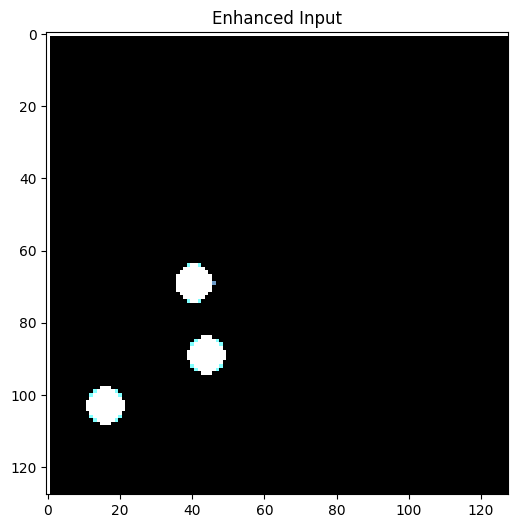

In [17]:
train(data_path)

In [7]:
device = 'cuda'

In [19]:
model = torch.load('/kaggle/working/model.pt', weights_only=False).to('cuda')

In [9]:
model.eval()
ds = Datasett(data_path, resize=(64, 64))

x = ds[10].unsqueeze(0).to(device)

In [14]:
with torch.no_grad():
    recon, slot_imgs = model(x)
    
x = x.cpu()
recon = recon.cpu()
slot_imgs = slot_imgs.cpu()

In [69]:
slot_imgs.shape

torch.Size([1, 5, 64])

In [70]:
slot_imgs[0, 1].shape

torch.Size([64])

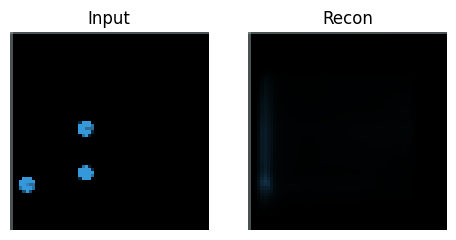

In [15]:
K = slot_imgs.shape[1]

plt.figure(figsize=(3*(K+2), 3))

# input
plt.subplot(1, K+2, 1)
plt.title("Input")
plt.imshow(x[0].permute(1,2,0))
plt.axis("off")

# recon
plt.subplot(1, K+2, 2)
plt.title("Recon")
plt.imshow(recon[0].permute(1,2,0))
plt.axis("off")

plt.show()

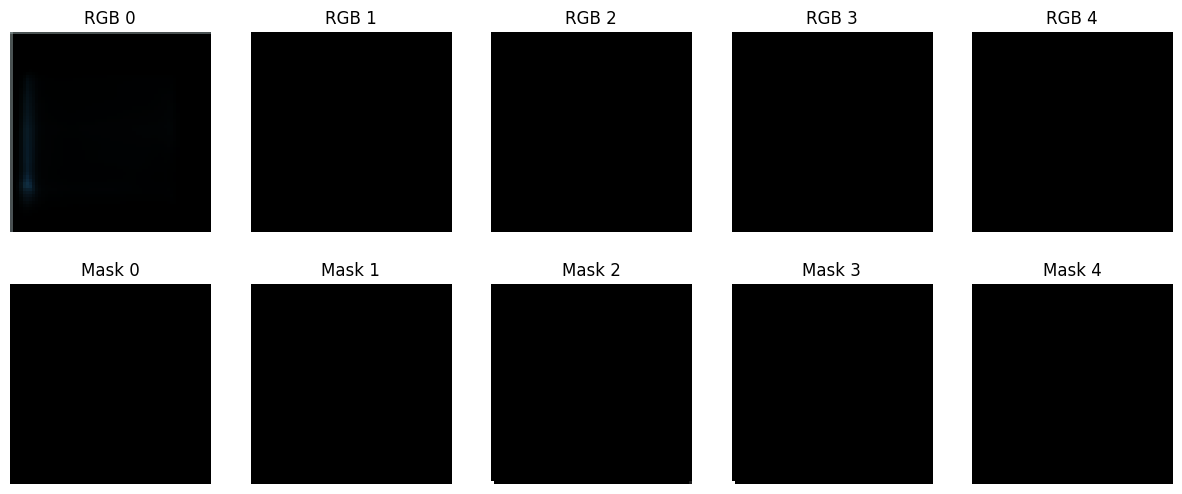

In [12]:
with torch.no_grad():
    recon, slots = model(x)

B, K, D = slots.shape
H, W = x.shape[-2:]

# ---- spatial broadcast ----
slots_ = slots.view(B*K, D, 1, 1).expand(-1, -1, H, W)

y = torch.linspace(-1, 1, H, device=slots.device)
xg = torch.linspace(-1, 1, W, device=slots.device)
yy, xx = torch.meshgrid(y, xg, indexing="ij")
coords = torch.stack([xx, yy], dim=0).unsqueeze(0)
coords = coords.expand(B*K, -1, -1, -1)

inp = torch.cat([slots_, coords], dim=1)
out = model.decoder.net(inp)
out = out.view(B, K, 4, H, W)

rgb = torch.sigmoid(out[:, :, :3])
masks = F.softmax(out[:, :, 3:4], dim=1)

plt.figure(figsize=(3*K, 6))

for k in range(K):
    plt.subplot(2, K, k+1)
    plt.imshow(rgb[0, k].permute(1,2,0).detach().cpu())
    plt.title(f"RGB {k}")
    plt.axis("off")

    plt.subplot(2, K, K+k+1)
    plt.imshow(masks[0, k, 0].detach().cpu(), cmap="gray")
    plt.title(f"Mask {k}")
    plt.axis("off")

plt.show()